# Holme–Newman model: opinions and relationships change together

**Learning objective:** explore how copying opinions and rewiring relationships can produce agreement within a fragmented network.

People may become similar because they interact, or choose to interact because they are similar. This model lets us ask:

- Can agreement along every relationship coexist with several opinions?
- How does the balance between copying and rewiring affect the network?
- Which observations depend on one random realization?

The network and the opinion dynamics are both theoretical mechanisms, not a reconstruction of a real population.

## The Holme–Newman model

Each agent $i$ holds a categorical opinion $g_i \in \{0,\ldots,G-1\}$. The numbers are labels: distances and arithmetic means between them have no meaning.

At each asynchronous attempt, choose agent $i$ uniformly. An isolated agent does nothing. Otherwise select an incident edge end uniformly, identifying an edge $(i,j)$, and choose between:

$$
\begin{array}{ll}
\text{probability }\phi: & (i,j)\longrightarrow(i,k),\quad
 k\text{ uniform among all agents with }g_k=g_i,\\
\text{probability }1-\phi: & g_i\longleftarrow g_j.
\end{array}
$$

Rewiring changes a relationship; copying changes only the focal agent's opinion.

### Conventions used here

- **Population and topology:** by default $N=100$ agents and $M=200$ undirected edges. Both counts stay fixed, while degrees and connected components may change. The initial network need not be connected.
- **Initial conditions:** independently sample both endpoints of each edge uniformly with replacement, and each agent's opinion uniformly from $G=10$ labels. Thus $\langle k\rangle=2M/N=4$ and $\gamma=N/G=10$.
- **Loops and parallel edges:** allowed initially and during rewiring, as in the original paper. The target set includes the focal agent, existing neighbors, and the previous neighbor.
- **Sampling convention:** choose nodes uniformly, not edges globally. Parallel edges give repeated opportunities to interact; a self-loop contributes two incident ends to degree and sampling. Copying across a loop does nothing.
- **No filtering by disagreement:** an agreeing edge can also be selected and rewired. Skipping all such attempts would change the process.
- **Schedule and influence:** asynchronous node-update; the focal agent copies its selected neighbor, never the reverse. There is no confidence threshold.
- **Time:** one sweep is $N$ attempted updates, including attempts that change nothing. It is not a synchronous round.
- **Stopping rule:** stop at the first state with zero disagreeing edges, or after \`MAX_SWEEPS\`. Record the initial state, every sweep, and the exact final attempt.
- **Agreement versus consensus:** zero disagreeing edges means every connected component is internally unanimous; global consensus requires one opinion across all agents, including isolates.
- **Parameter ranges:** integer \`N_AGENTS >= 1\`, \`N_EDGES >= 0\`, \`N_OPINIONS >= 1\`, \`MAX_SWEEPS >= 0\`; both rewiring probabilities lie in $[0,1]$. Prefer at most 20 labels for readable categorical colors.

Zero disagreement does **not** freeze the whole graph: further same-opinion rewiring could still rearrange, split, or join same-opinion components. We stop at the first arrival at edge agreement, without simulating that subsequent rearrangement.

In [1]:
import random

import igraph as ig
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Adjustable parameters
N_AGENTS = 100
N_EDGES = 200
N_OPINIONS = 10
MAX_SWEEPS = 500
REWIRING_PROBABILITY = 0.20
COMPARISON_REWIRING_PROBABILITY = 0.80

# Independent streams for topology, opinions, drawing, and dynamics.
NETWORK_SEED = 2026
OPINION_SEED = 2027
LAYOUT_SEED = 2028
DYNAMICS_SEED = 2029

assert isinstance(N_AGENTS, int) and N_AGENTS >= 1
assert isinstance(N_EDGES, int) and N_EDGES >= 0
assert isinstance(N_OPINIONS, int) and N_OPINIONS >= 1
assert isinstance(MAX_SWEEPS, int) and MAX_SWEEPS >= 0
assert 0 <= REWIRING_PROBABILITY <= 1
assert 0 <= COMPARISON_REWIRING_PROBABILITY <= 1

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

## 1. Create the social network

We use `igraph` to store, lay out, modify, and draw the network. Unlike the fixed small-world graph in the DeGroot notebook, this model starts from a random multigraph and changes relationships during the simulation.

The NumPy generator samples each endpoint independently. We do not simplify the graph or discard isolated vertices. The drawing uses one seeded layout throughout, so moving nodes cannot be mistaken for rewiring. Seeds reproduce results within a software environment; exact trajectories can differ across library versions.

In [2]:
network_rng = np.random.default_rng(NETWORK_SEED)
initial_edges = network_rng.integers(
    N_AGENTS, size=(N_EDGES, 2),
).tolist()
initial_graph = ig.Graph(
    n=N_AGENTS, edges=initial_edges, directed=False,
)

opinion_rng = np.random.default_rng(OPINION_SEED)
initial_opinions = opinion_rng.integers(N_OPINIONS, size=N_AGENTS)

ig.set_random_number_generator(random.Random(LAYOUT_SEED))
layout_rng = np.random.default_rng(LAYOUT_SEED)
layout_start = layout_rng.uniform(-1.0, 1.0, size=(N_AGENTS, 2))
layout = initial_graph.layout_fruchterman_reingold(
    seed=layout_start.tolist(),
)

assert initial_graph.vs.indices == list(range(N_AGENTS))
assert sum(initial_graph.degree()) == 2 * N_EDGES

print(f"Agents: {initial_graph.vcount()}")
print(f"Edges (including loops and parallel edges): {initial_graph.ecount()}")
print(f"Initial connected components: {len(initial_graph.connected_components())}")
print(f"Mean degree: {2 * N_EDGES / N_AGENTS:.2f}")
print(f"Agents per possible opinion, gamma: {N_AGENTS / N_OPINIONS:.2f}")

Agents: 100
Edges (including loops and parallel edges): 200
Initial connected components: 2
Mean degree: 4.00
Agents per possible opinion, gamma: 10.00


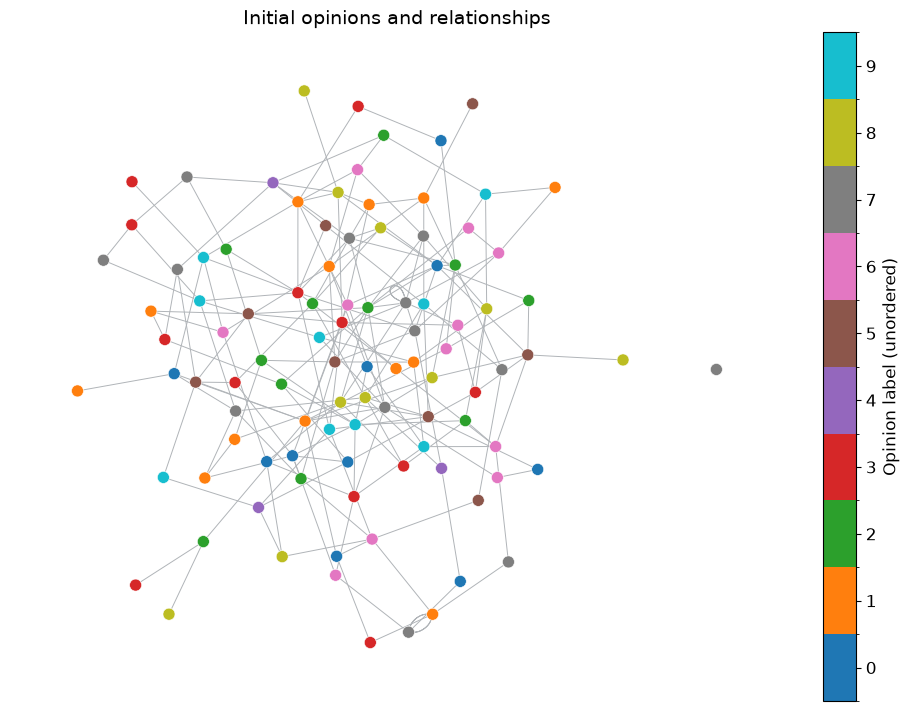

In [3]:
# Categorical colors: adjacent labels are not similar opinions.
palette = plt.colormaps["tab10" if N_OPINIONS <= 10 else "tab20"]
opinion_colors = [
    mcolors.to_hex(palette(index % palette.N))
    for index in range(N_OPINIONS)
]
opinion_cmap = mcolors.ListedColormap(opinion_colors)
opinion_norm = mcolors.BoundaryNorm(
    np.arange(N_OPINIONS + 1) - 0.5, N_OPINIONS,
)
opinion_color_scale = plt.cm.ScalarMappable(
    norm=opinion_norm, cmap=opinion_cmap,
)


def draw_opinion_network(ax, graph, opinions, title, vertex_size=10):
    """Draw the current graph with fixed vertex positions and label colors."""
    ig.plot(
        graph,
        target=ax,
        layout=layout,
        vertex_color=[opinion_colors[value] for value in opinions],
        vertex_size=vertex_size,
        vertex_frame_color="white",
        vertex_frame_width=0.4,
        vertex_label=None,
        edge_color="#b0b4b8",
        edge_width=0.7,
        autocurve=True,
    )
    ax.set_title(title)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
draw_opinion_network(
    ax, initial_graph, initial_opinions,
    "Initial opinions and relationships", vertex_size=12,
)
fig.colorbar(
    opinion_color_scale, ax=ax,
    ticks=np.arange(N_OPINIONS), label="Opinion label (unordered)",
)
plt.show()

## 2. Translate the theory into code

The transition function implements one attempted update. It changes the supplied graph or opinion array in place; the simulation wrapper will copy both inputs first.

`graph.incident(i)` lists incident edge IDs, counting a self-loop twice in an undirected graph. Sampling this list implements the stated edge-end convention. In particular, we do not convert the neighbors into a set, which would lose edge multiplicity.

Deleting the selected edge and adding its replacement preserves $M$. The target is selected from **all** current holders of the focal opinion, so that target set is never empty.

In [4]:
def count_disagreeing_edges(graph, opinions):
    """Count each edge once; loops always connect equal opinions."""
    return sum(
        opinions[source] != opinions[target]
        for source, target in graph.get_edgelist()
    )


def holme_newman_step(graph, opinions, rewiring_probability, rng):
    """One node-first attempt; mutate only the supplied simulation state."""
    focal = int(rng.integers(graph.vcount()))
    incident_edges = graph.incident(focal)
    if not incident_edges:
        return

    edge_id = int(rng.choice(incident_edges))
    source, target = graph.es[edge_id].tuple
    neighbor = target if source == focal else source

    if rng.random() < rewiring_probability:
        same_opinion = np.flatnonzero(opinions == opinions[focal])
        new_neighbor = int(rng.choice(same_opinion))
        graph.delete_edges([edge_id])
        graph.add_edge(focal, new_neighbor)
    else:
        opinions[focal] = opinions[neighbor]


# Hand-check: either endpoint copies the other on a two-node graph.
test_graph = ig.Graph(n=2, edges=[(0, 1)])
test_opinions = np.array([0, 1])
holme_newman_step(
    test_graph, test_opinions, 0.0, np.random.default_rng(7),
)
assert test_opinions[0] == test_opinions[1]
assert test_graph.get_edgelist() == [(0, 1)]

# A loop contributes two incident ends, alongside each parallel edge.
test_multigraph = ig.Graph(n=2, edges=[(0, 0), (0, 1), (0, 1)])
assert len(test_multigraph.incident(0)) == test_multigraph.degree(0) == 4

## 3. Run asynchronous Holme–Newman updates

We store opinion snapshots and observables once per sweep, plus the exact stopping time. The graph itself is retained only at the start and end to keep the example small.

Every attempt counts toward time, even if the chosen agent is isolated or copies an identical opinion. The stopping test is evaluated after every attempt. A run reaching the time limit with disagreeing edges is reported as unfinished, not as a final segregated state.

In [5]:
def simulate_holme_newman(
    graph, initial_state, rewiring_probability, max_sweeps, rng,
):
    """Return a copied final graph, sampled opinions, and network observables."""
    initial_state = np.asarray(initial_state)
    assert not graph.is_directed()
    assert graph.vcount() >= 1
    assert initial_state.shape == (graph.vcount(),)
    assert np.issubdtype(initial_state.dtype, np.integer)
    assert np.all(initial_state >= 0)
    assert 0 <= rewiring_probability <= 1
    assert isinstance(max_sweeps, (int, np.integer)) and max_sweeps >= 0

    current_graph = graph.copy()
    opinions = initial_state.copy()
    n_agents, n_edges = graph.vcount(), graph.ecount()
    max_attempts = n_agents * max_sweeps
    attempts, history, disagreement, largest_component = [], [], [], []

    def record(attempt, active_edges):
        attempts.append(attempt)
        history.append(opinions.copy())
        disagreement.append(active_edges / n_edges if n_edges else 0.0)
        largest_component.append(
            max(current_graph.connected_components().sizes()) / n_agents
        )

    active_edges = count_disagreeing_edges(current_graph, opinions)
    record(0, active_edges)

    for attempt in range(1, max_attempts + 1):
        if active_edges == 0:
            break
        holme_newman_step(current_graph, opinions, rewiring_probability, rng)
        active_edges = count_disagreeing_edges(current_graph, opinions)
        if attempt % n_agents == 0 or active_edges == 0 or attempt == max_attempts:
            record(attempt, active_edges)

    history = np.asarray(history)
    assert current_graph.vcount() == n_agents
    assert current_graph.ecount() == n_edges
    assert sum(current_graph.degree()) == 2 * n_edges
    assert np.all(np.isin(history, initial_state))

    return {
        "graph": current_graph,
        "opinions": history,
        "attempts": np.asarray(attempts),
        "sweeps": np.asarray(attempts) / n_agents,
        "disagreement": np.asarray(disagreement),
        "largest_component": np.asarray(largest_component),
        "edge_agreement": active_edges == 0,
    }


result = simulate_holme_newman(
    initial_graph, initial_opinions,
    REWIRING_PROBABILITY, MAX_SWEEPS,
    np.random.default_rng(DYNAMICS_SEED),
)
final_graph = result["graph"]
final_opinions = result["opinions"][-1]

print(f"Recorded duration: {result['sweeps'][-1]:.2f} sweeps")
print("Reached zero disagreeing edges:", result["edge_agreement"])
print("Global consensus:", np.unique(final_opinions).size == 1)
print("Surviving opinions:", np.unique(final_opinions).size)
print("Final connected components:", len(final_graph.connected_components()))

Recorded duration: 157.86 sweeps
Reached zero disagreeing edges: True
Global consensus: False
Surviving opinions: 7
Final connected components: 12


## 4. Compare the initial and final states

Both panels use the same vertex positions and categorical colors, but the edges can change. Curves show parallel edges and self-loops; dense overlaps are best interpreted together with the component statistics.

The final panel is a snapshot at the stopping rule or time limit. Same-colored vertices need not belong to the same connected component.

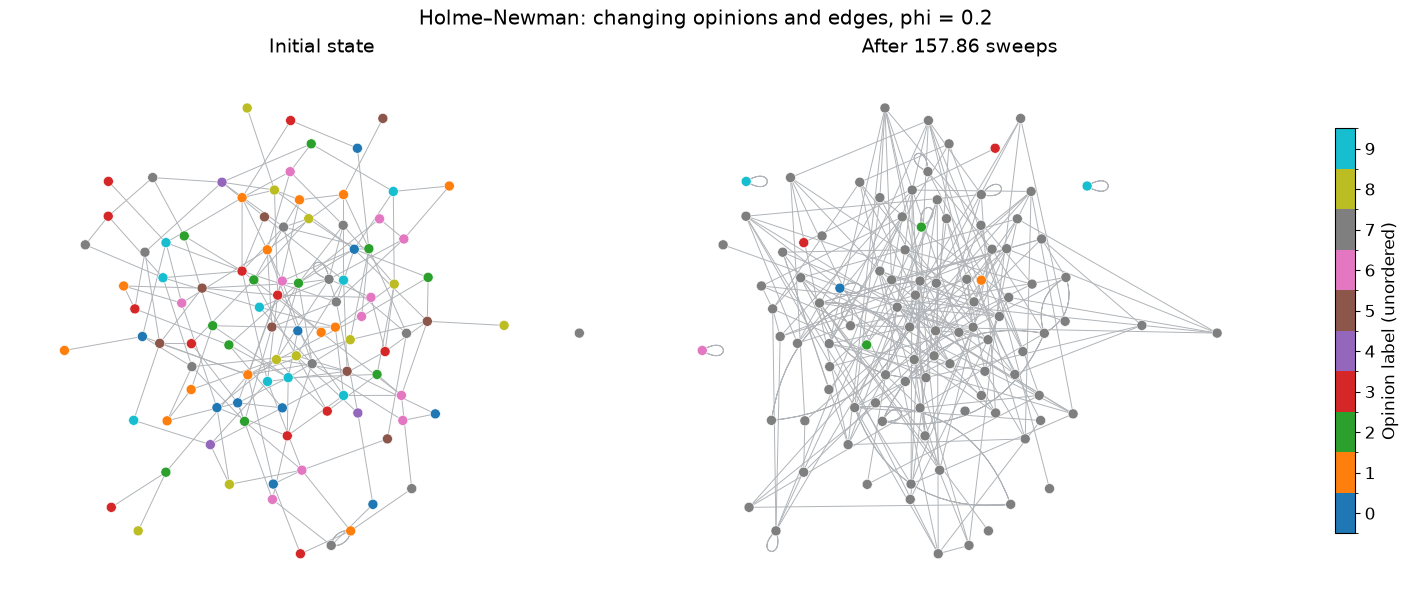

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
draw_opinion_network(
    axes[0], initial_graph, initial_opinions, "Initial state",
)
draw_opinion_network(
    axes[1], final_graph, final_opinions,
    f"After {result['sweeps'][-1]:.2f} sweeps",
)
fig.colorbar(
    opinion_color_scale, ax=axes,
    ticks=np.arange(N_OPINIONS),
    label="Opinion label (unordered)", shrink=0.75,
)
fig.suptitle(
    f"Holme-Newman: changing opinions and edges, phi = {REWIRING_PROBABILITY:g}"
)
plt.show()

## 5. A typical analysis: agreement or fragmentation?

For categorical opinions, a numerical opinion range would depend on arbitrary labels. Instead, measure the fraction of edges whose endpoints disagree:

$$
\rho(t)=\frac{1}{M}\sum_{e=(i,j)}\mathbf{1}[g_i(t)\ne g_j(t)].
$$

Each parallel edge counts separately. Self-loops enter the denominator but never the numerator; for an edgeless graph we define $\rho=0$.

We also track the largest connected component as a fraction of $N$, and each opinion's population share. Component size and opinion-group size are different quantities: one opinion can occupy several disconnected components.

Copying may **increase** disagreement in an individual step. Rewiring cannot increase it, but need not decrease it. Thus, monotone decay is not an invariant of the combined process.

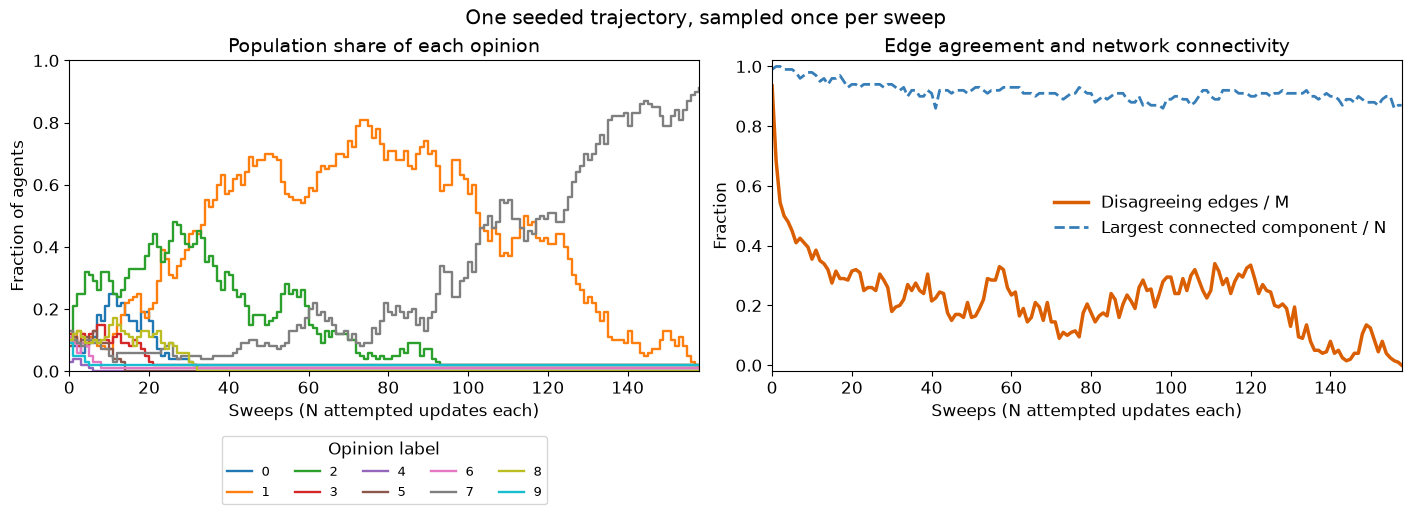

Every connected component is internally unanimous at stopping.
Final disagreeing-edge fraction: 0.000
Largest component / N: 0.870


In [7]:
opinion_fractions = np.stack([
    np.mean(result["opinions"] == label, axis=1)
    for label in range(N_OPINIONS)
], axis=1)
assert np.allclose(opinion_fractions.sum(axis=1), 1.0)
time_limit = max(1.0, float(result["sweeps"][-1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
for label in range(N_OPINIONS):
    axes[0].step(
        result["sweeps"], opinion_fractions[:, label],
        where="post", color=opinion_colors[label],
        linewidth=1.7, label=str(label),
    )
axes[0].set(
    title="Population share of each opinion",
    xlabel="Sweeps (N attempted updates each)", ylabel="Fraction of agents",
    xlim=(0, time_limit), ylim=(0, 1),
)
axes[0].legend(
    title="Opinion label", ncol=min(5, N_OPINIONS),
    fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.19),
)

axes[1].plot(
    result["sweeps"], result["disagreement"],
    color="#d95f02", linewidth=2.5, label="Disagreeing edges / M",
)
axes[1].plot(
    result["sweeps"], result["largest_component"],
    color="#377eb8", linestyle="--", linewidth=2,
    label="Largest connected component / N",
)
axes[1].set(
    title="Edge agreement and network connectivity",
    xlabel="Sweeps (N attempted updates each)", ylabel="Fraction",
    xlim=(0, time_limit), ylim=(-0.02, 1.02),
)
axes[1].legend(frameon=False, loc="best")
fig.suptitle("One seeded trajectory, sampled once per sweep")
plt.show()

if result["edge_agreement"]:
    print("Every connected component is internally unanimous at stopping.")
else:
    print("Time limit reached: disagreeing edges remain; the run is unfinished.")
print(f"Final disagreeing-edge fraction: {result['disagreement'][-1]:.3f}")
print(f"Largest component / N: {result['largest_component'][-1]:.3f}")

## 6. A focused comparison: more copying or more rewiring?

Repeat the simulation with a higher rewiring probability, starting from exactly the same graph and opinions. Reset the dynamics generator to the same seed to make the comparison reproducible. The streams are not event-by-event matched: different branches and evolving neighborhoods consume randomness differently.

The first row compares endpoint networks at their respective stopping times. The second row compares opinion shares and component sizes, explicitly separating who agrees from who is connected. These two small runs illustrate possible outcomes; they do not locate a phase transition.

phi = 0.2: edge agreement; 7 opinions; 12 components; largest component sizes = [87, 2, 2, 1, 1]
phi = 0.8: edge agreement; 10 opinions; 13 components; largest component sizes = [20, 14, 11, 11, 10]


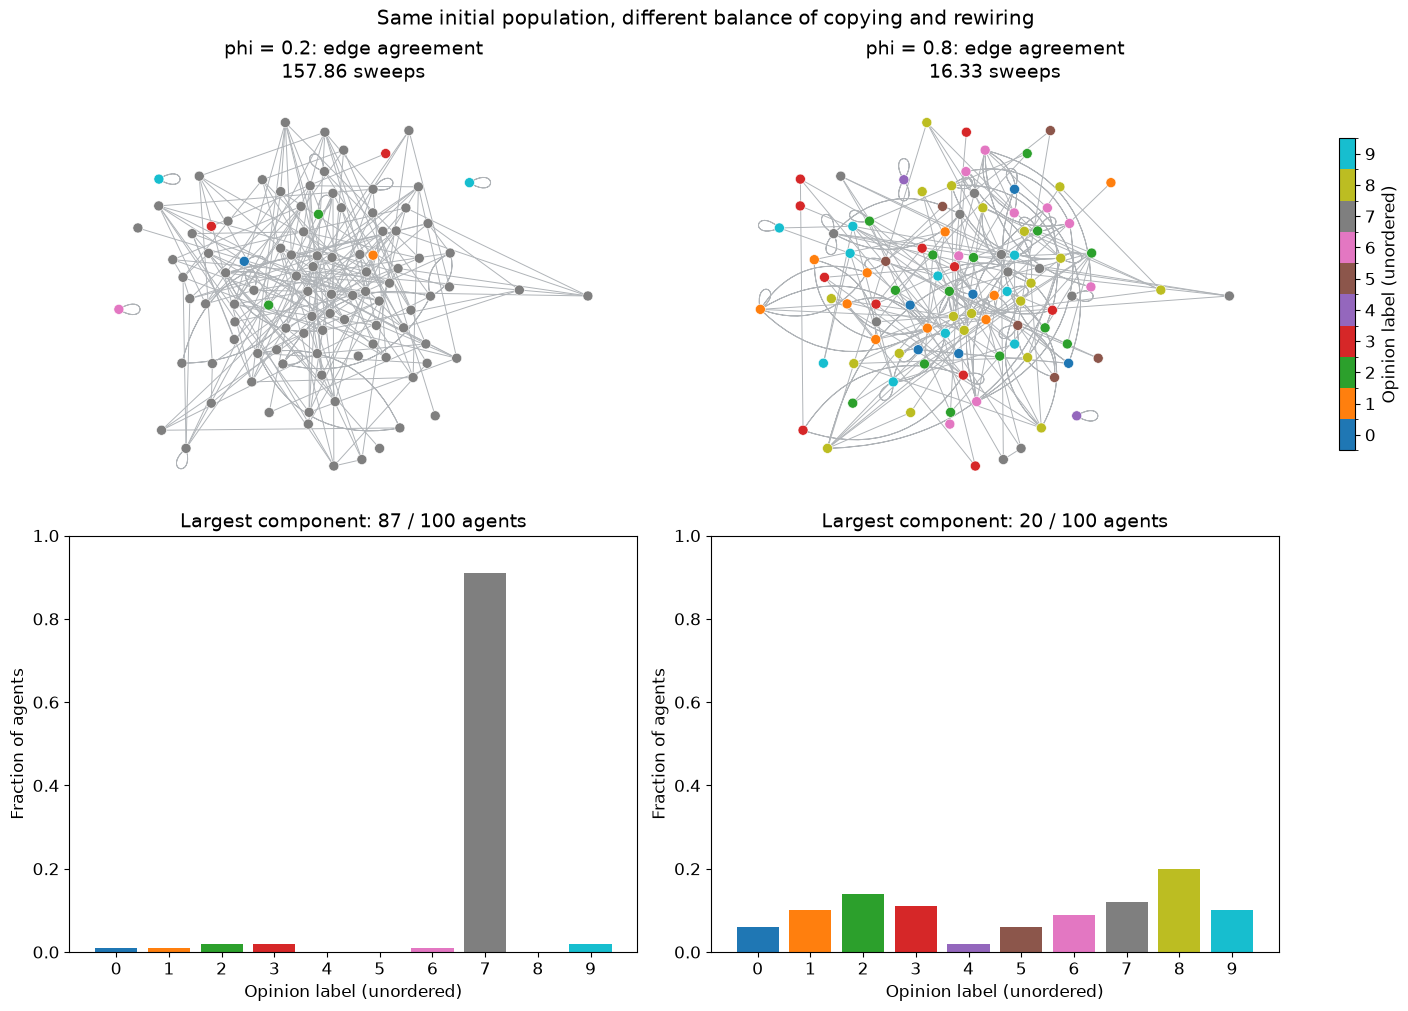

In [8]:
comparison = simulate_holme_newman(
    initial_graph, initial_opinions,
    COMPARISON_REWIRING_PROBABILITY, MAX_SWEEPS,
    np.random.default_rng(DYNAMICS_SEED),
)
runs = [
    (REWIRING_PROBABILITY, result),
    (COMPARISON_REWIRING_PROBABILITY, comparison),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
for column, (probability, run) in enumerate(runs):
    state = run["opinions"][-1]
    status = "edge agreement" if run["edge_agreement"] else "time limit"
    draw_opinion_network(
        axes[0, column], run["graph"], state,
        f"phi = {probability:g}: {status}\n"
        f"{run['sweeps'][-1]:.2f} sweeps",
    )
    shares = np.bincount(state, minlength=N_OPINIONS) / N_AGENTS
    axes[1, column].bar(
        np.arange(N_OPINIONS), shares, color=opinion_colors,
    )
    component_sizes = sorted(
        run["graph"].connected_components().sizes(), reverse=True,
    )
    axes[1, column].set(
        title=f"Largest component: {component_sizes[0]} / {N_AGENTS} agents",
        xlabel="Opinion label (unordered)", ylabel="Fraction of agents",
        xticks=np.arange(N_OPINIONS), ylim=(0, 1),
    )
    print(
        f"phi = {probability:g}: {status}; "
        f"{np.count_nonzero(shares)} opinions; "
        f"{len(component_sizes)} components; "
        f"largest component sizes = {component_sizes[:5]}"
    )

fig.colorbar(
    opinion_color_scale, ax=list(axes[0]),
    ticks=np.arange(N_OPINIONS),
    label="Opinion label (unordered)", shrink=0.75,
)
fig.suptitle("Same initial population, different balance of copying and rewiring")
plt.show()

## Interpretation and limitations

Copying can spread an opinion through existing relationships; rewiring can remove cross-opinion contacts without changing anyone's opinion. At zero disagreeing edges, agreement holds within each connected component but need not hold across the population.

Read the printed stopping status before interpreting an endpoint. The network can already be disconnected initially, and same-opinion rewiring can change component sizes even after edge agreement. The figures show first-arrival snapshots, not a permanently frozen topology.

The model preserves agent and edge counts, and cannot invent an opinion absent from the initial state. It does not preserve individual degrees or the population share of an opinion. Arithmetic averages of opinion labels are not meaningful observables.

This teaching example follows the paper's copying/rewiring mechanism with explicitly stated finite-multigraph conventions. A single small realization cannot establish a critical point, scaling law, or typical outcome. The original study uses ensembles and varying system sizes; reproducing that analysis requires more than comparing two seeds or probabilities.

Real relationships need not allow self-loops or repeated edges, and real opinions are not necessarily interchangeable categories. The model also omits external information, stubbornness, unequal trust, and the cost of forming new relationships.

### Suggested experiments

1. Try `REWIRING_PROBABILITY = 0` and `1`: the first keeps the topology fixed; the second keeps all opinions fixed.
2. Change the two rewiring probabilities and repeat several `DYNAMICS_SEED` values. Compare disagreement, surviving opinions, component sizes, and unfinished runs.
3. Change population size while keeping $2M/N$ and $N/G$ approximately fixed. Increase `MAX_SWEEPS` when runs remain unfinished; use aggregate statistics when there are too many opinion labels to distinguish by color.

### Original reference

Holme, P., & Newman, M. E. J. (2006). *Nonequilibrium phase transition in the coevolution of networks and opinions*. Physical Review E, 74, 056108. [doi:10.1103/PhysRevE.74.056108](https://doi.org/10.1103/PhysRevE.74.056108). [Open preprint](https://arxiv.org/abs/physics/0603023).